In [74]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.sparse import csc_matrix
from sksparse.cholmod import cholesky

Importazione matrice e termine noto del sistema lineare:

In [75]:
def ImportaMatriceCSC(N, tipo_ordinamento):
    file_da_leggere = f"../dati/A{N}{tipo_ordinamento}.txt"

    r, c, v = np.loadtxt(file_da_leggere, unpack=True)
    r = r.astype(np.int32)      # di default sono float
    c = c.astype(np.int32)

    A_csc = csc_matrix((v,(r,c)), shape=(N**2, N**2))

    return A_csc

def ImportaRhs(N, tipo_ordinamento):
    file_da_leggere = f"../dati/rhs{N}{tipo_ordinamento}.txt"

    b = np.loadtxt(file_da_leggere)
    
    return b

Funzioni per la fattorizzazione e la soluzione del sistema lineare:

In [76]:
def CalcolaCholesky(A):
    factor = cholesky(A, ordering_method="natural")
    return csc_matrix(factor.L())

In [77]:
def RisolviSistema(L, b):
    y = scipy.sparse.linalg.spsolve_triangular(L, -b)
    u = scipy.sparse.linalg.spsolve_triangular(L.T, y, lower=False)
    return u

Funzioni per passare da ordine naturale/riordinato dei nodi interni a (i,j), e dall'ordine del bordo a (i,j):

In [78]:
def GeneraMappaNaturale(N):                         # mappa da n (ordine naturale) a (i,j)
    file_da_leggere = f"../dati/coords{N}.txt"

    mappa_nat_inv = np.loadtxt(file_da_leggere, usecols=(1, 2), dtype=np.int32)

    return mappa_nat_inv

def GeneraMappaOrdinata(N):                         # mappa da m (riordinamento) a (i,j)
    file_da_leggere = f"../dati/ordering{N}.txt"

    mappa_m_n = np.loadtxt(file_da_leggere, usecols=(1), dtype=np.int32)

    mappa_nat_inv = GeneraMappaNaturale(N)

    mappa_ord_inv = mappa_nat_inv[mappa_m_n]

    return mappa_ord_inv

def GeneraMappaBordo(N):                            # mappa da {0,...,4N+3} a (i,j) del bordo
    mappa = np.zeros((4 * N + 4, 2), dtype=np.int32)

    k1 = np.arange(0, N+2)          # lato sinistro
    mappa[k1, 0] = 0
    mappa[k1, 1] = k1

    k2 = np.arange(N+2, 2*N+3)      # lato in alto
    mappa[k2, 0] = k2 - (N + 1)
    mappa[k2, 1] = N + 1

    k3 = np.arange(2*N+3, 3*N+4)    # lato a destra 
    mappa[k3, 0] = N + 1
    mappa[k3, 1] = 3*N + 3 - k3

    k4 = np.arange(3*N+4, 4*N+4)    # lato in basso
    mappa[k4, 0] = 4*N + 4 - k4
    mappa[k4, 1] = 0

    return mappa

Funzione per disegnare la soluzione:

In [88]:
def DisegnaSoluzione(N, tipo_ordinamento, u, u0 = None):
    
    h = 1.0 / (N + 1)       # passo del reticolo
    
    if u0 is None:                  # di default i valori sul bordo sono 0
        u0 = np.zeros(4*N + 4)

    mappa_bordo = GeneraMappaBordo(N)

    if tipo_ordinamento == "nat":
        mappa_interna = GeneraMappaNaturale(N)
    elif tipo_ordinamento == "ord":
        mappa_interna = GeneraMappaOrdinata(N)

    coord = np.vstack((mappa_interna, mappa_bordo))
    x = coord[:,0] * h
    y = coord[:,1] * h

    sol = np.concatenate((u,u0))

    plt.figure()
    plt.scatter(x, y, c = sol, cmap = 'jet', s = 2)
    plt.colorbar(label = "Temperatura")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(0,1)
    plt.ylim(0,1)

    plt.show()

Esempio di struttura delle matrici $A,L$:

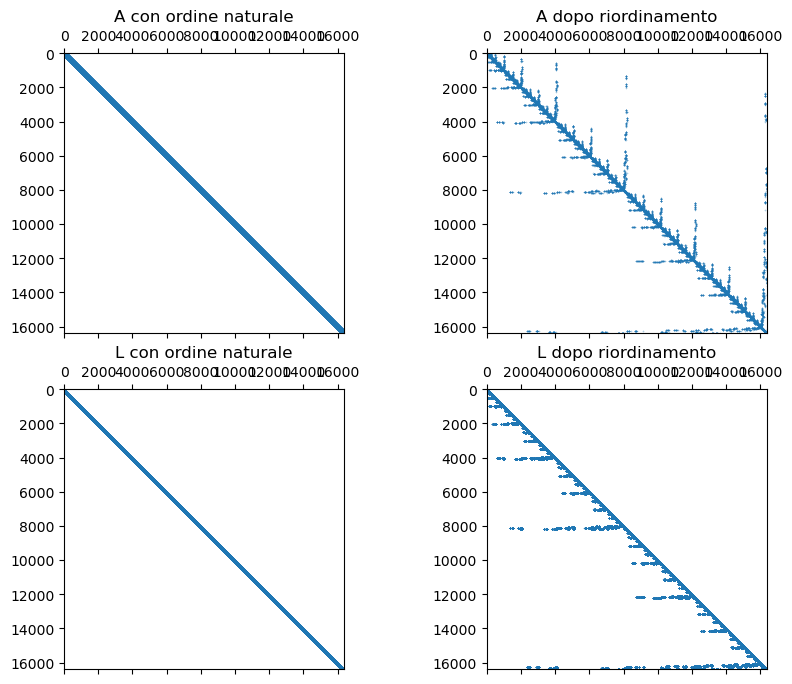

In [109]:
N = 128

A1 = ImportaMatriceCSC(128, "nat")
L1 = CalcolaCholesky(-A1)

A2 = ImportaMatriceCSC(128, "ord")
L2 = CalcolaCholesky(-A2)

plt.figure(figsize=(10, 8))
plt.subplot(2,2,1)
plt.spy(A1, markersize = 0.1)
plt.title("A con ordine naturale")

plt.subplot(2,2,2)
plt.spy(A2, markersize = 0.1)
plt.title("A dopo riordinamento")

plt.subplot(2,2,3)
plt.spy(L1, markersize = 0.1)
plt.title("L con ordine naturale")

plt.subplot(2,2,4)
plt.spy(L2, markersize = 0.1)
plt.title("L dopo riordinamento")
plt.show()

Esempio di grafico della soluzione:

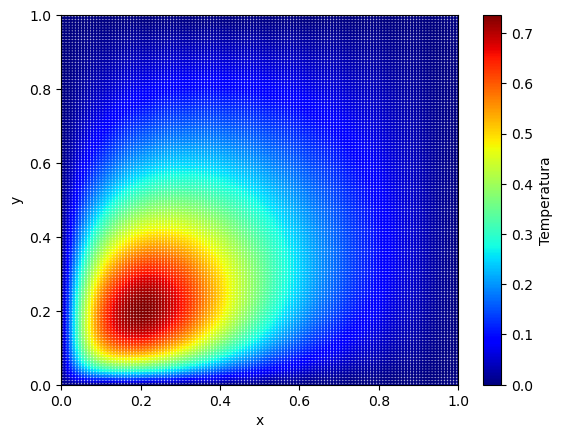

In [ ]:
N = 128
tipo_ordinamento = "ord"

A = ImportaMatriceCSC(N, tipo_ordinamento)
b = ImportaRhs(N, tipo_ordinamento)
L = CalcolaCholesky(-A)
u = RisolviSistema(L, b)

DisegnaSoluzione(N, tipo_ordinamento, u)